# Pre exploratary data analysis thoughts on Data:

1. Uniform Time stamps in data (assuming the row number is the timestamp, since no other column resembles timestamp data)
2. Based on looking at the data, I believe column 1 is our price  (will plot this)
3. I will plot a histogram and time series for all columns, I am aware some of this data is not in time series form but it is easier to plot all of it to see if we can interpret anything.

# Start of Assignment

In [116]:
import pandas as pd
df = pd.read_csv("TEST_Trader_Quant_dataset.csv")

In [117]:
df.shape

(8688, 56)

# Data Cleanup
1. Checking for any NAN values in the data

In [118]:
df.isna().sum()

1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
50    0
51    0
52    0
53    0
54    0
55    0
56    0
dtype: int64

# Visualisation and stats of Column 1

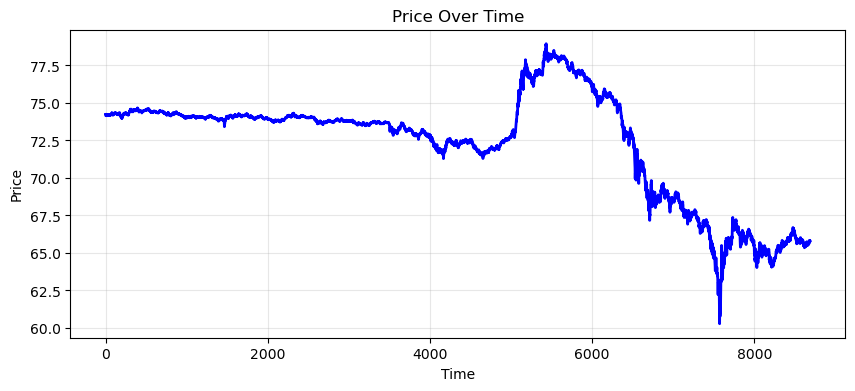

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df.index, df['1'], color='blue', linewidth=2)
plt.title('Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(alpha=0.3)
plt.show()

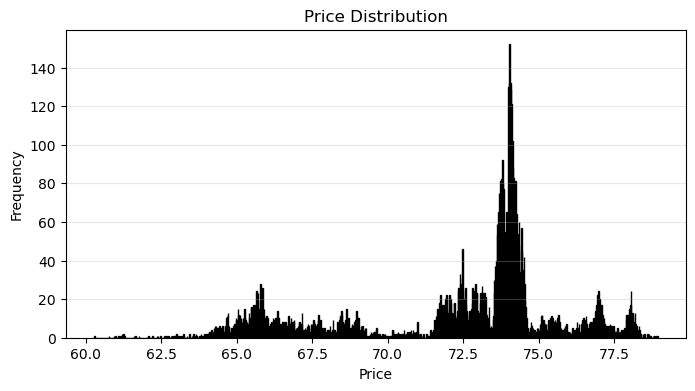

In [120]:
plt.figure(figsize=(8, 4))
plt.hist(df['1'], bins=1000, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


# Findings, Target Variable Creation and Train-Test Split.

1. These visualisations of the histogram and time series of column 1 suggest that this column is the price.

2. I will aim to predict this but using the returns of the values in this column; this is because returns are stationary. 

3. So, the target variable is the next-day return derived from the price series, and the remaining features are used as predictors.

4. From looking at the other columns, there does not seem to be one that resembles returns. I will transform price to create a column for returns and treat this as my target.

5. Since I will be fitting a model to predict this target, I will do an 80/20 time-based train/test split on the data and perform correlation checks using the train data.

In [121]:
import numpy as np
col_returns = np.zeros(len(df)) 
for i in range(1, len(df)):
    col_returns[i] = (df['1'].iloc[i] - df['1'].iloc[i-1]) / df['1'].iloc[i-1]

df['57'] = col_returns
df['57'] = df['57'].shift(-1) # Shifting returns 1 day ahead to prevent look ahead bias

I am predicting next day returns to explore whether the features can anticipate short term future movements in asset returns

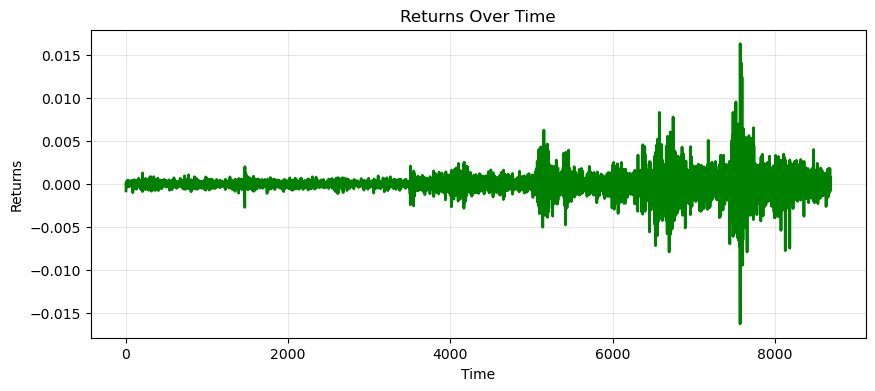

In [122]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['57'], color='green', linewidth=2)
plt.title('Returns Over Time')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.grid(alpha=0.3)
plt.show()

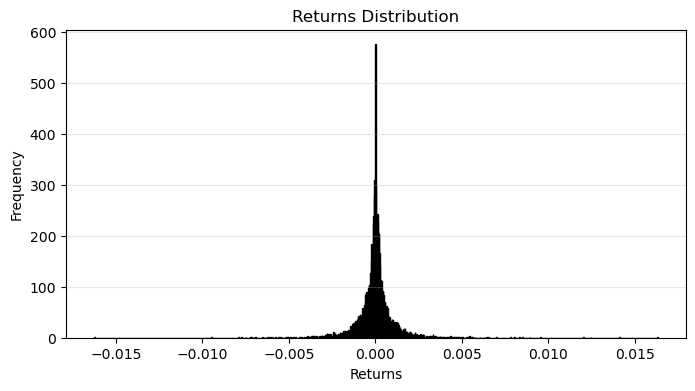

In [123]:
plt.figure(figsize=(8, 4))
plt.hist(df['57'], bins=1000, color='lightgreen', edgecolor='black')
plt.title('Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

These diagrams help to visualise the returns in the train data set. We see that towards the latter half of the time interval there appears to be higher volatility in the returns. 

The histogram suggests returns are normally distributed, with a mean of 1, as expected.

There are a few outliers, but robust models should be able to deal with this; no clipping/removal of data data points will be performed.

In [124]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

# Histogram and Time Series for all features
I will plot each feature's Histogram and Line plot using Matplotlib as before.

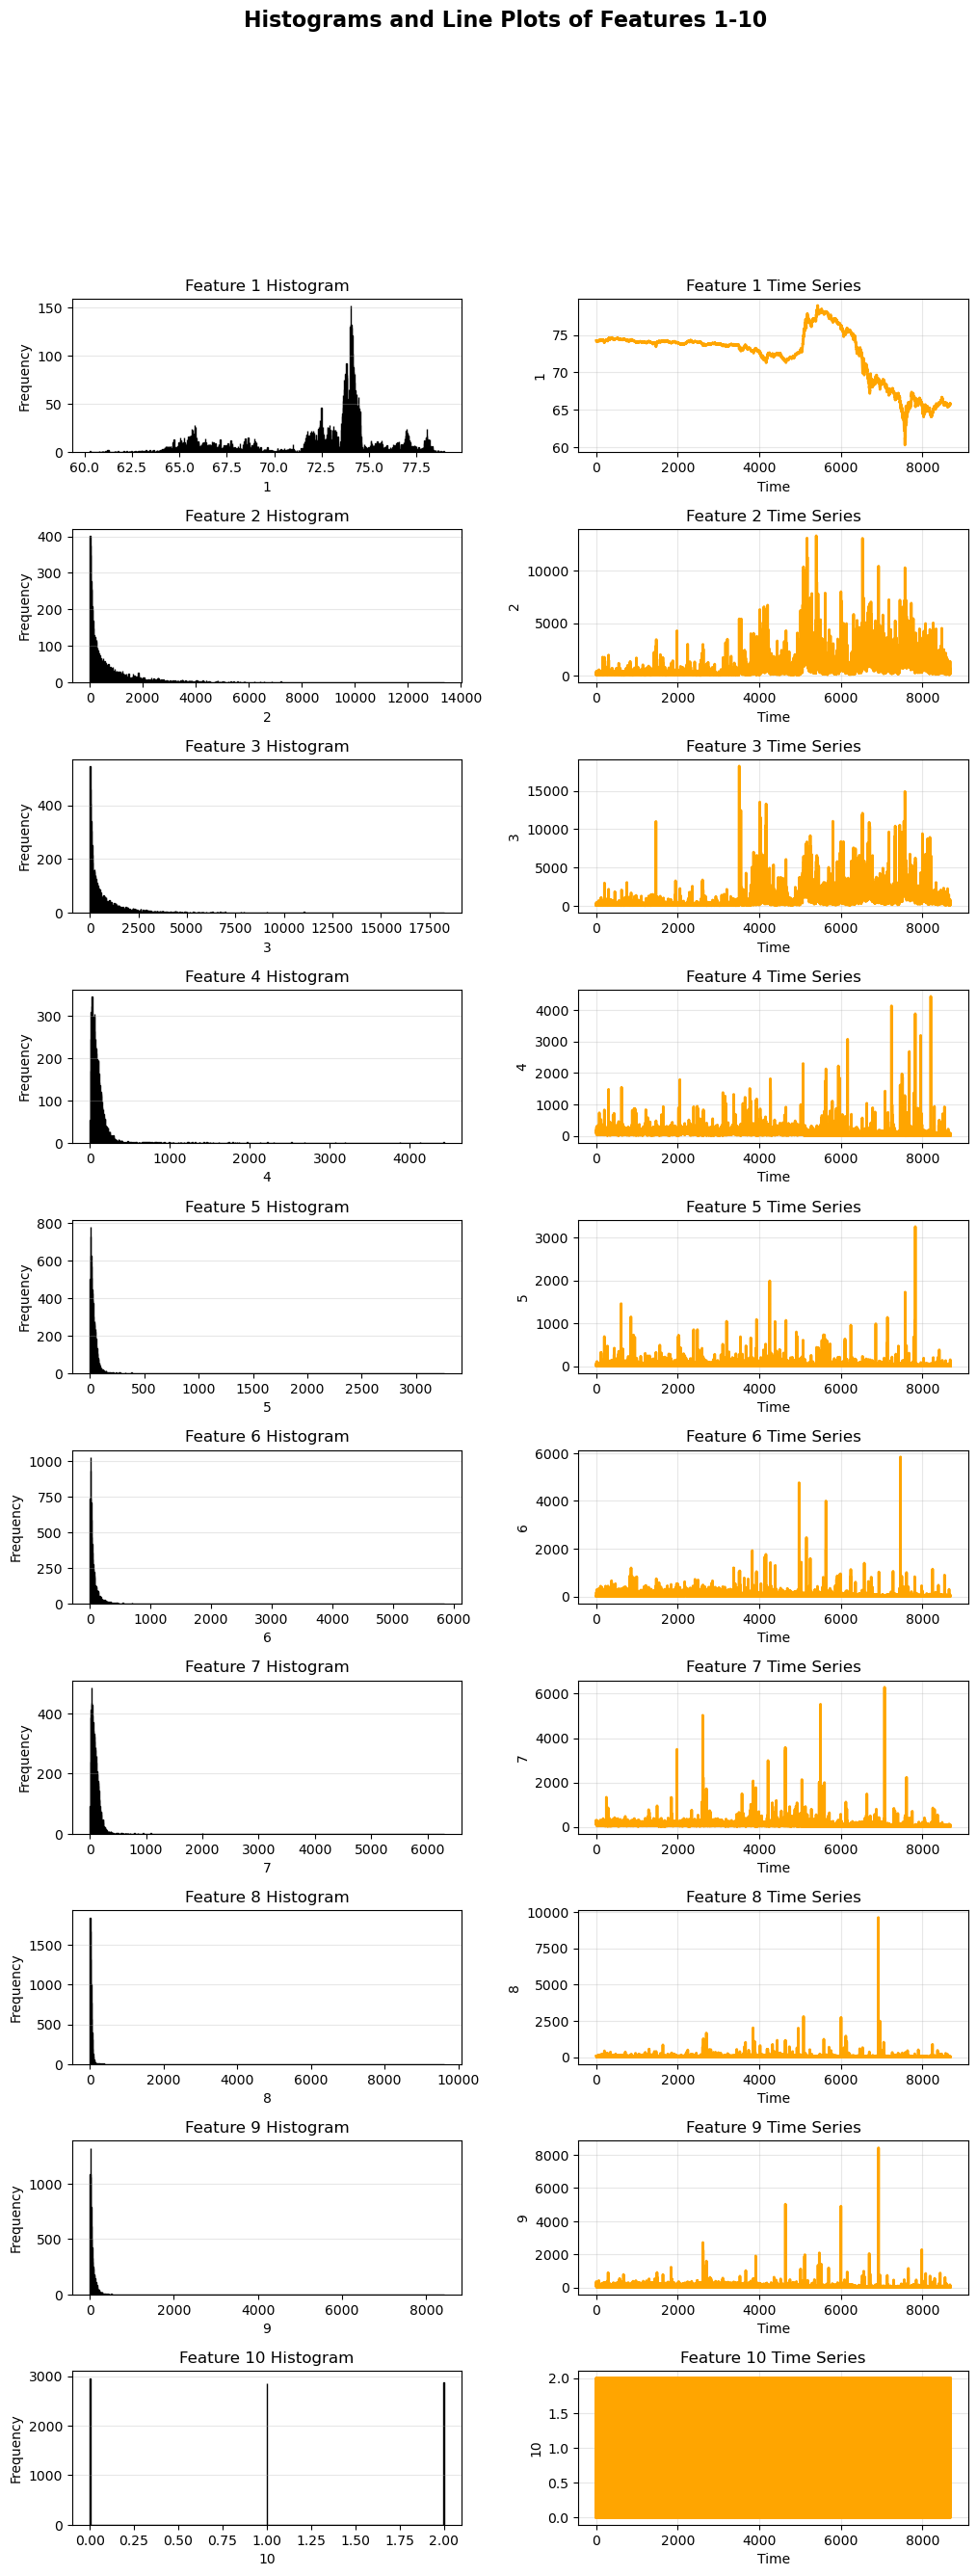

In [125]:
cols_to_plot = [str(i) for i in range(1, 11)]  # First 10 columns
n = len(cols_to_plot)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(cols_to_plot):
    # Histogram
    axes[i, 0].hist(df[col], bins=1000, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Feature {col} Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Line plot
    axes[i, 1].plot(df.index, df[col], color='orange', linewidth=2)
    axes[i, 1].set_title(f'Feature {col} Time Series')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Histograms and Line Plots of Features 1-10', fontsize=16, fontweight='bold')
plt.show()


### Observations

1. Feature 1 Seems, as mentioned before, to represent asset price.

2. Features 2-9 all represent highly oscillating patterns, with them slightly resembling a lognormal distribution.

3. Feature 10 is a discrete feature ranging from 0 to 2 (could be the current trend of the market – 0: neutral, 1: up, 2: down).

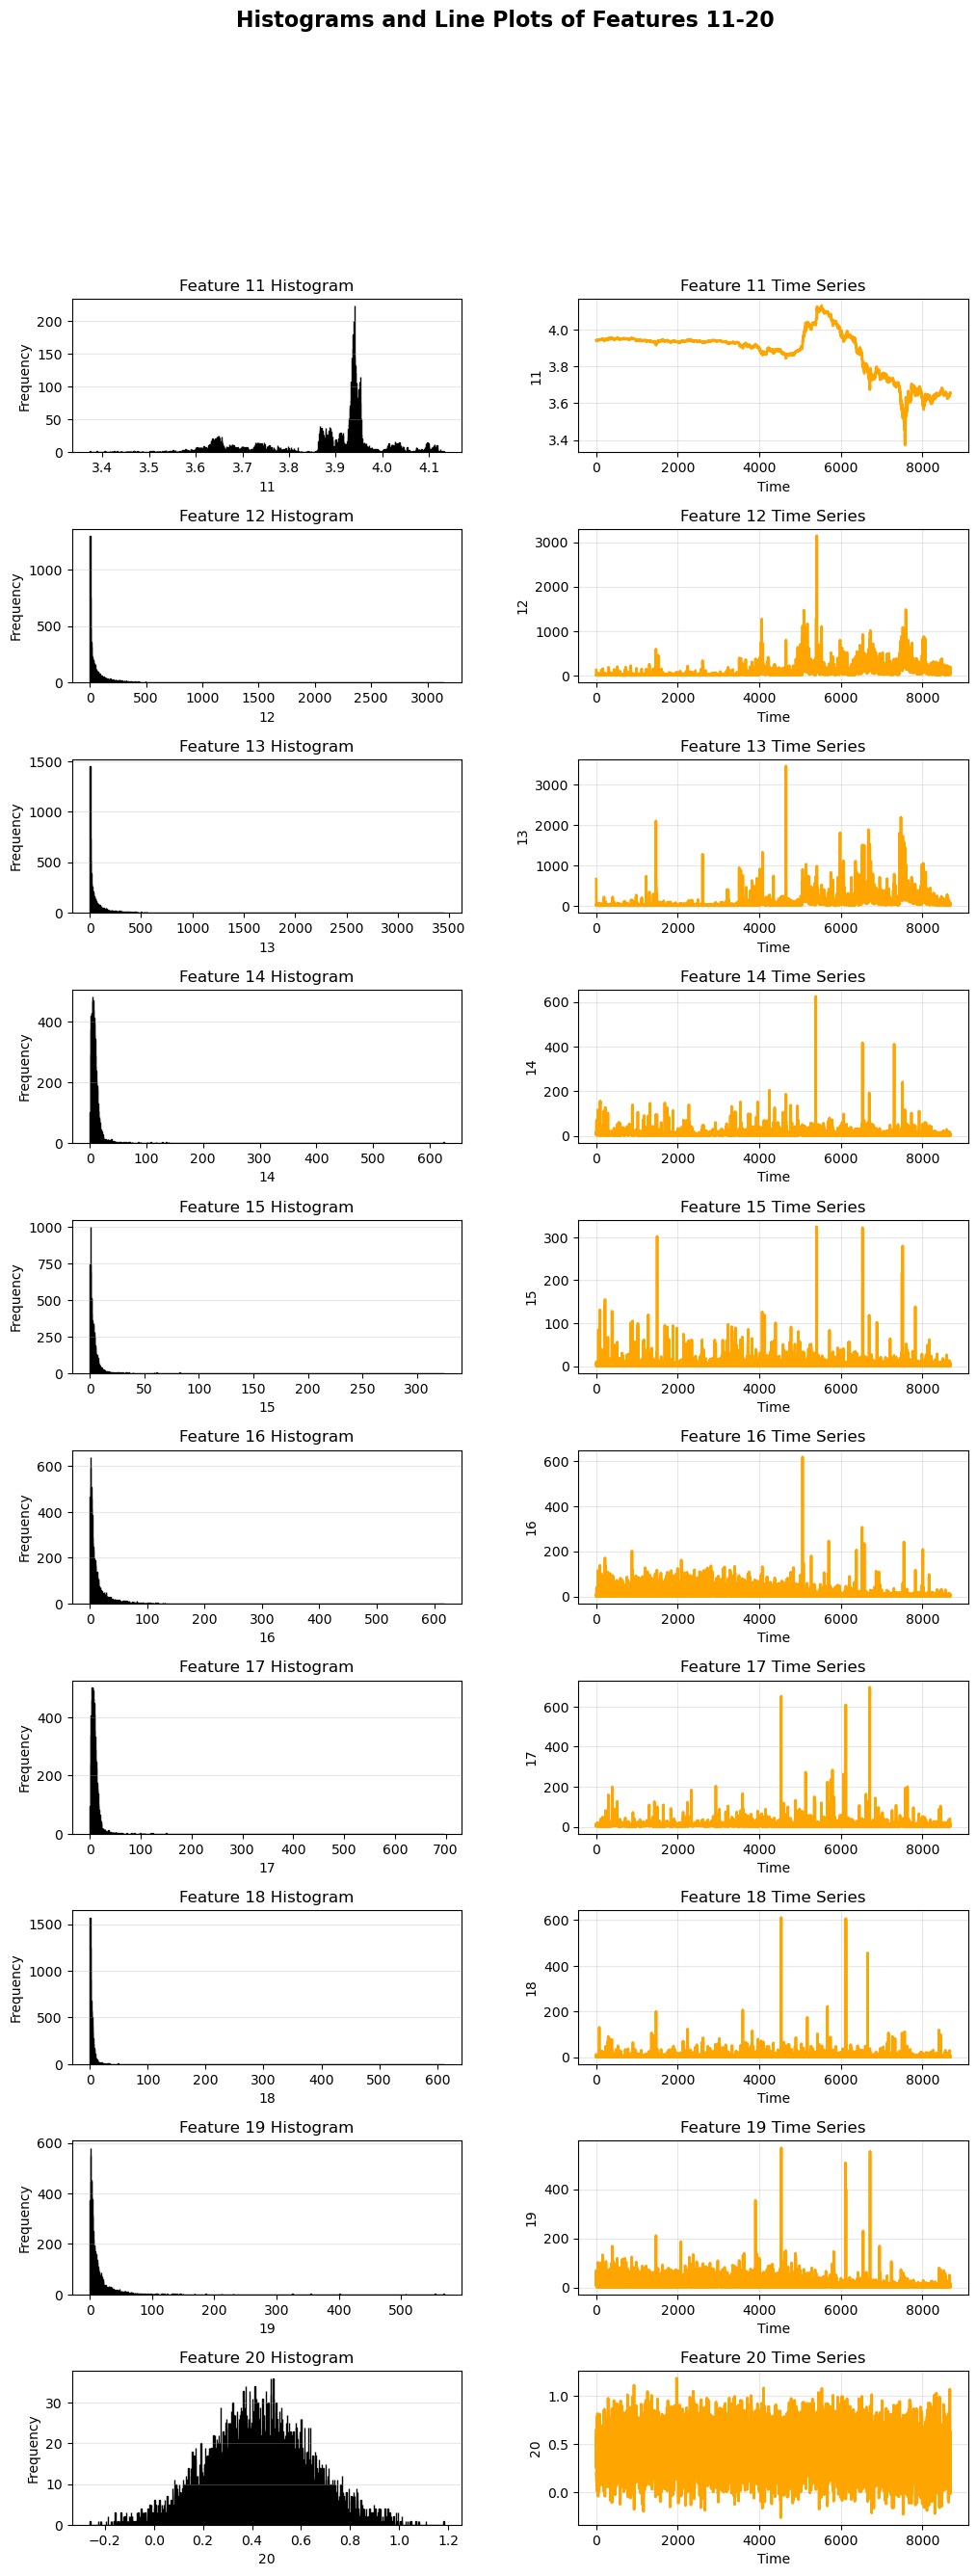

In [126]:
cols_to_plot = [str(i) for i in range(11, 21)]  # Next 10 columns
n = len(cols_to_plot)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(cols_to_plot):
    # Histogram
    axes[i, 0].hist(df[col], bins=1000, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Feature {col} Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Line plot
    axes[i, 1].plot(df.index, df[col], color='orange', linewidth=2)
    axes[i, 1].set_title(f'Feature {col} Time Series')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Histograms and Line Plots of Features 11-20', fontsize=16, fontweight='bold')
plt.show()


### Observations

1. Feature 11 is very similar looking to feature 1, so it is most likely a transformation of it.

2. Features 12-19 also all represent highly oscillating patterns, with them also slightly resembling a lognormal distribution.

3. Figure 20 shows a normal distribution with a mean of around 0.43. This could be something engineered, like an EMA difference.

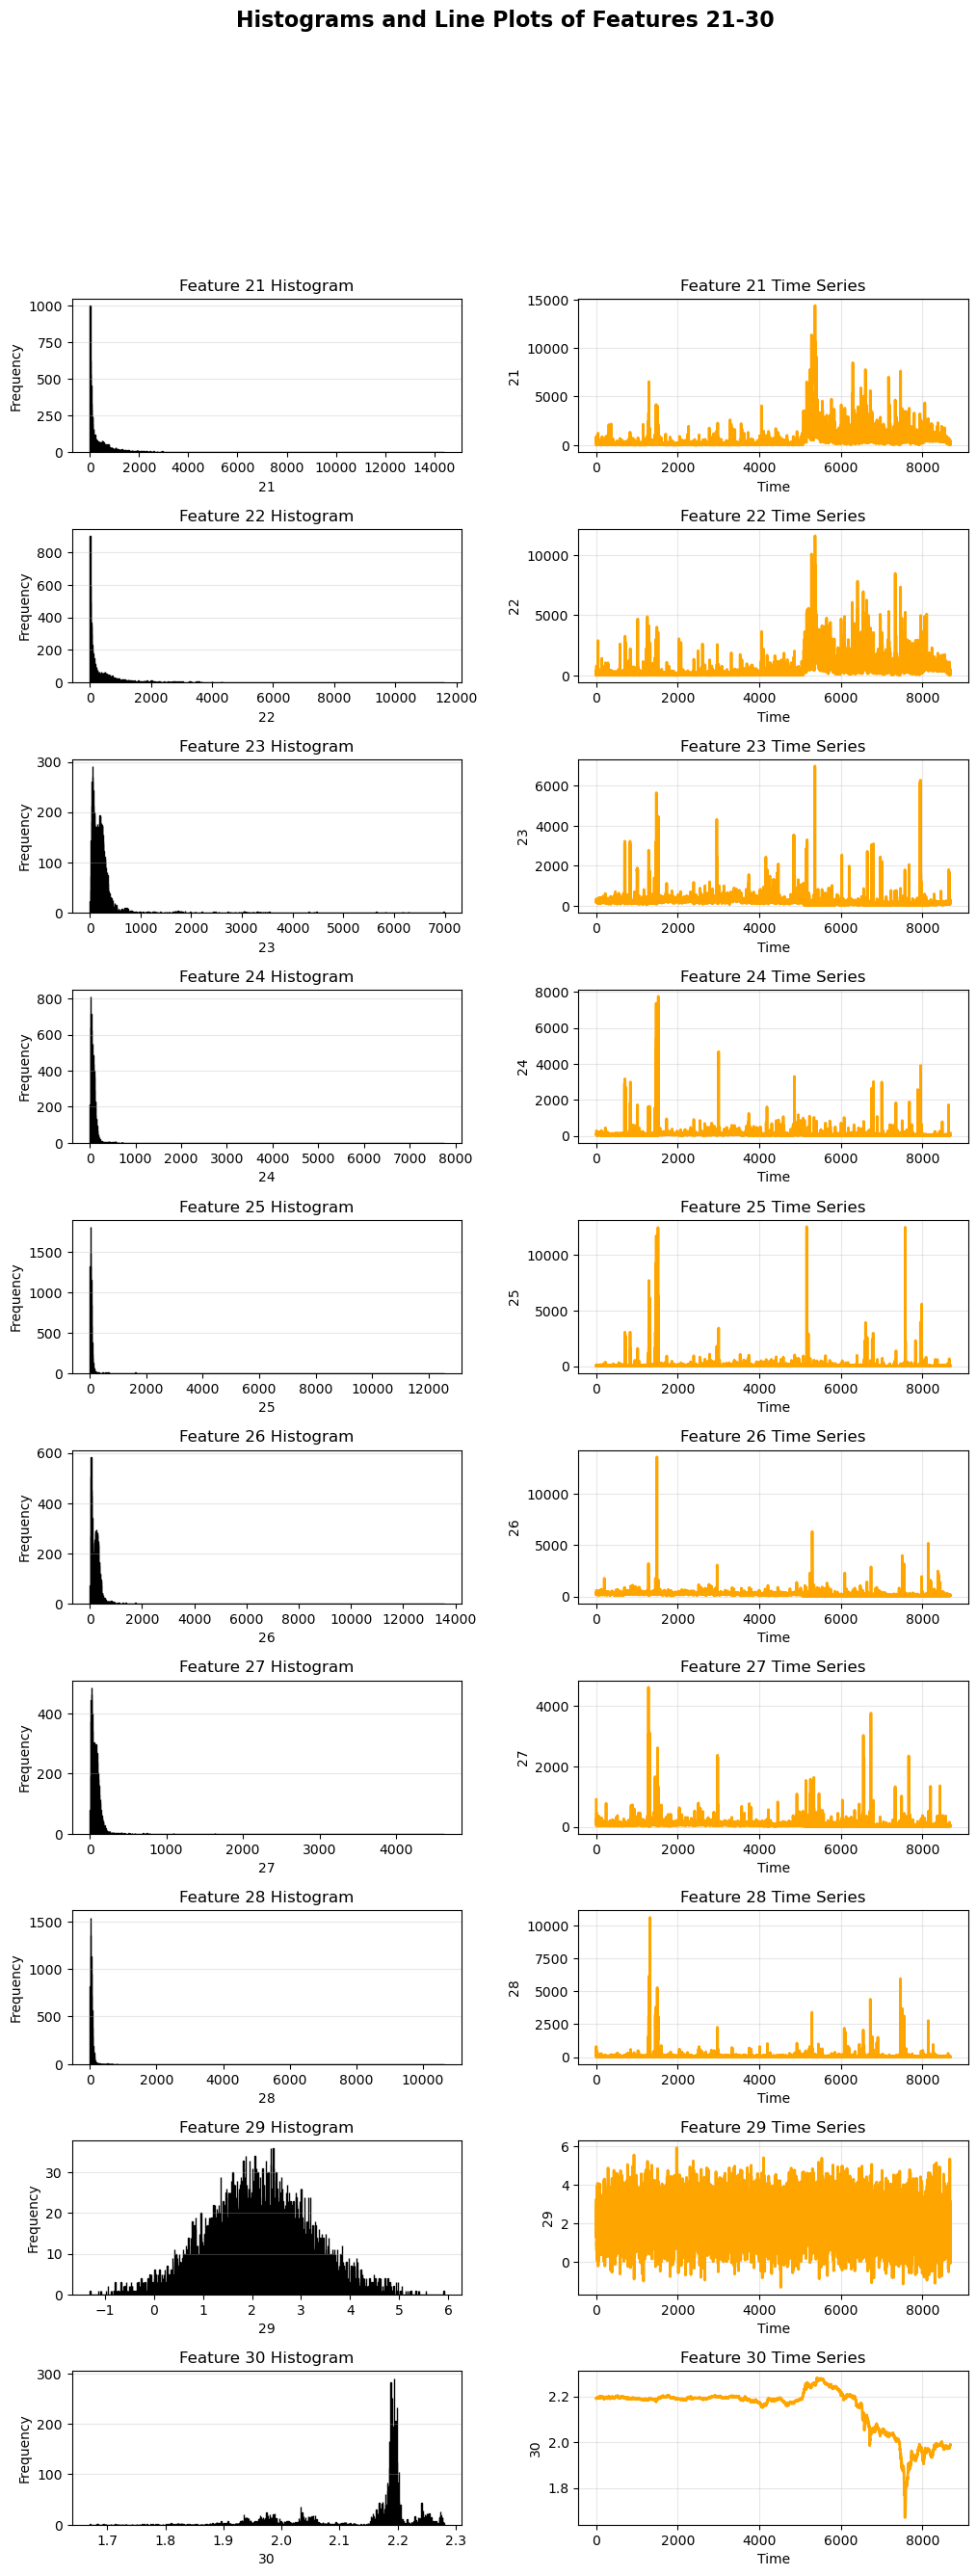

In [127]:
cols_to_plot = [str(i) for i in range(21, 31)]  # Next 10 columns
n = len(cols_to_plot)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(cols_to_plot):
    # Histogram
    axes[i, 0].hist(df[col], bins=1000, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Feature {col} Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Line plot
    axes[i, 1].plot(df.index, df[col], color='orange', linewidth=2)
    axes[i, 1].set_title(f'Feature {col} Time Series')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Histograms and Line Plots of Features 21-30', fontsize=16, fontweight='bold')
plt.show()


### Observations

1. Again, features 21-28 are highly oscillating and very difficult to interpret.

2. Feature 29 looks identical to Feature 20 and could be a scalar multiple of each other.

3. Feature 30 looks very similar to features 1 and 11. This is also most likely a transformation of column 1.

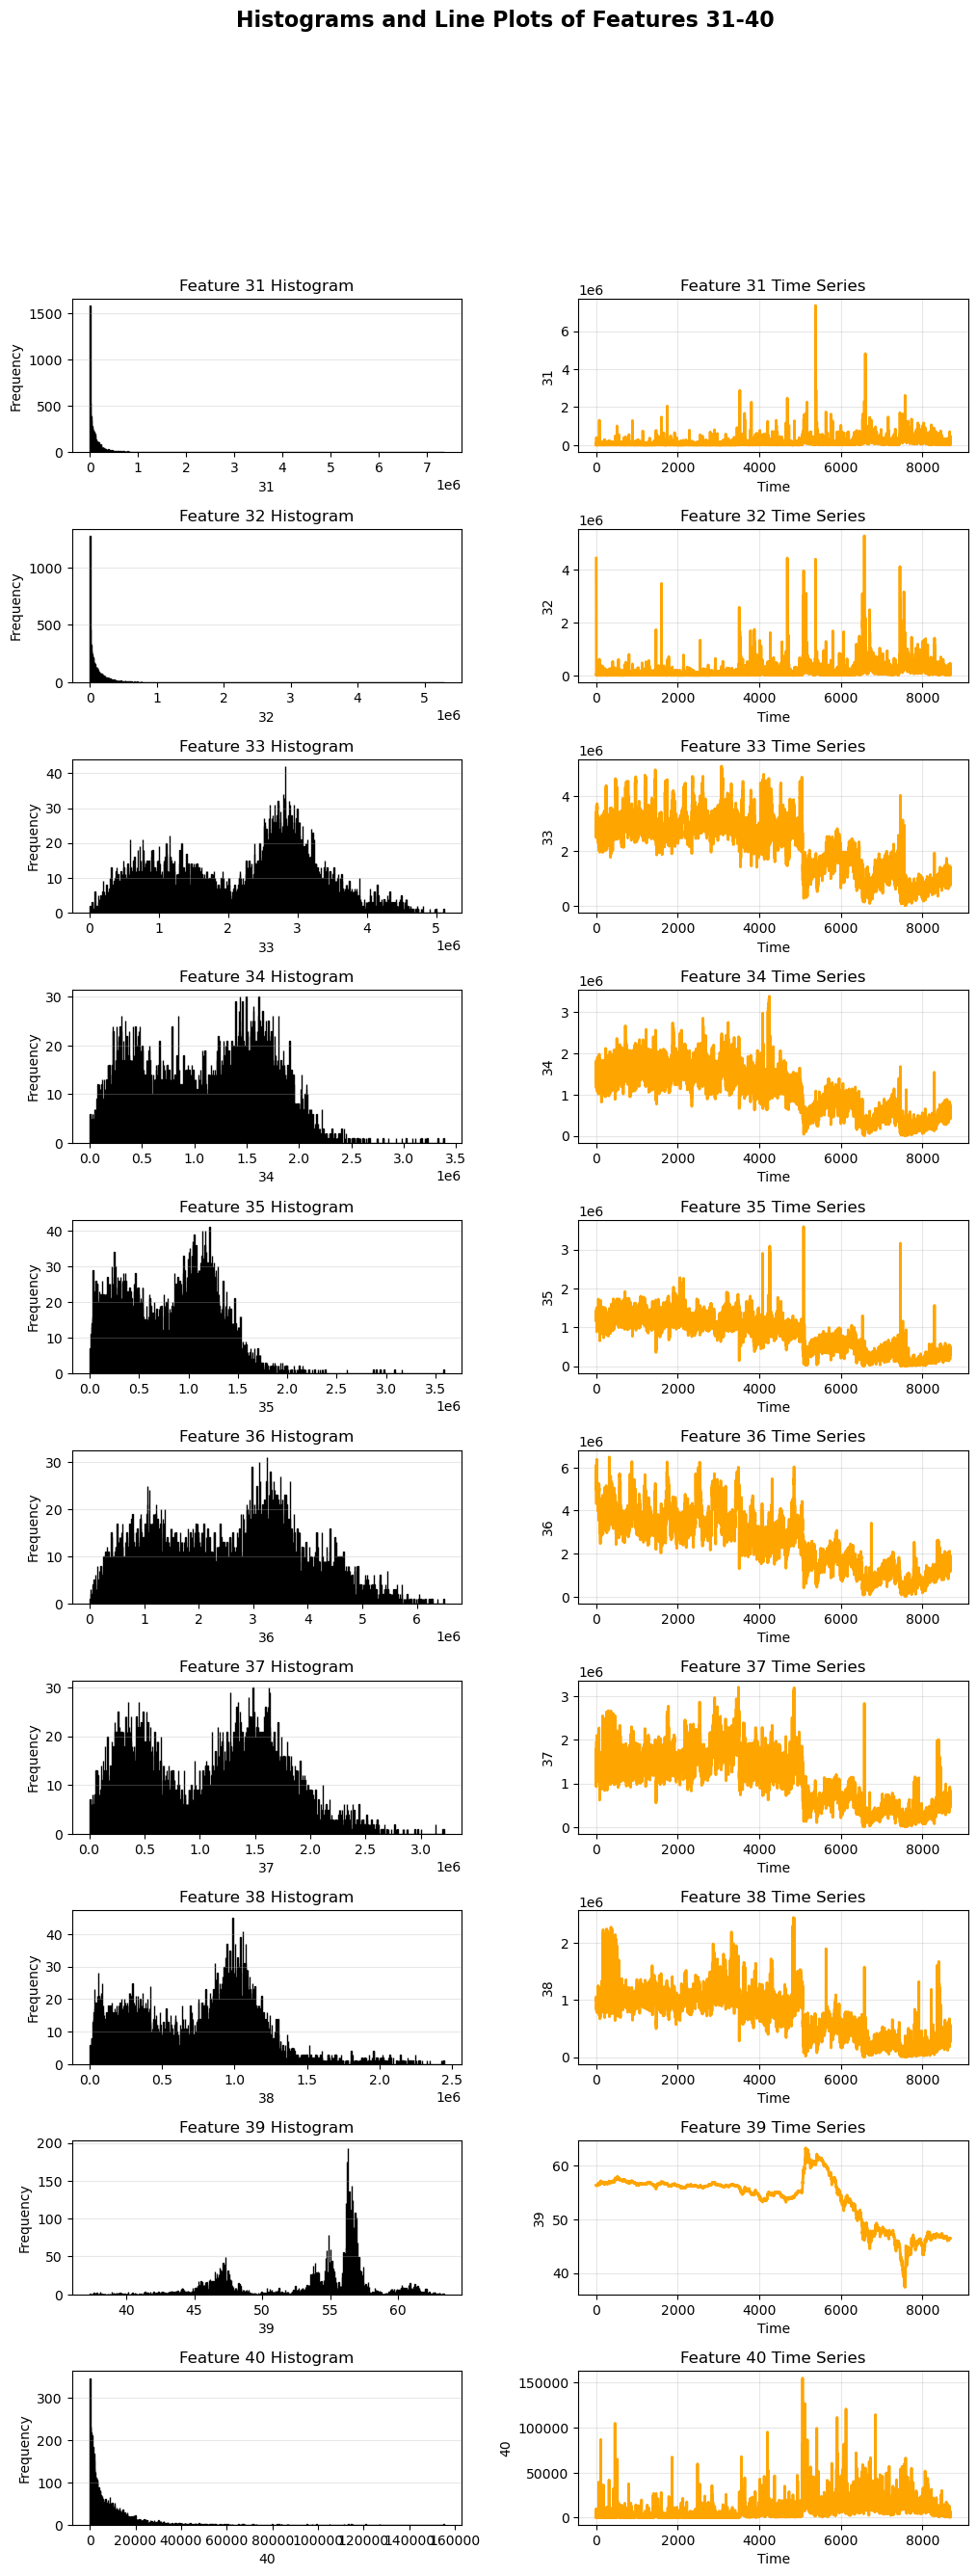

In [128]:
cols_to_plot = [str(i) for i in range(31, 41)]  # Next 10 columns
n = len(cols_to_plot)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(cols_to_plot):
    # Histogram
    axes[i, 0].hist(df[col], bins=1000, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Feature {col} Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Line plot
    axes[i, 1].plot(df.index, df[col], color='orange', linewidth=2)
    axes[i, 1].set_title(f'Feature {col} Time Series')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Histograms and Line Plots of Features 31-40', fontsize=16, fontweight='bold')
plt.show()


### Observations

1. Features 31, 32 and 40 are also highly oscillating and hard to interpret.

2. Features 33-38 are normally distributed, all with high values ranging in the millions. These are most likely engineered features, such as a different form of EMA difference or order book pressure.

3. Feature 30, like 39 and 11, looks very similar to feature 1. Could also be a transformation of one of them.

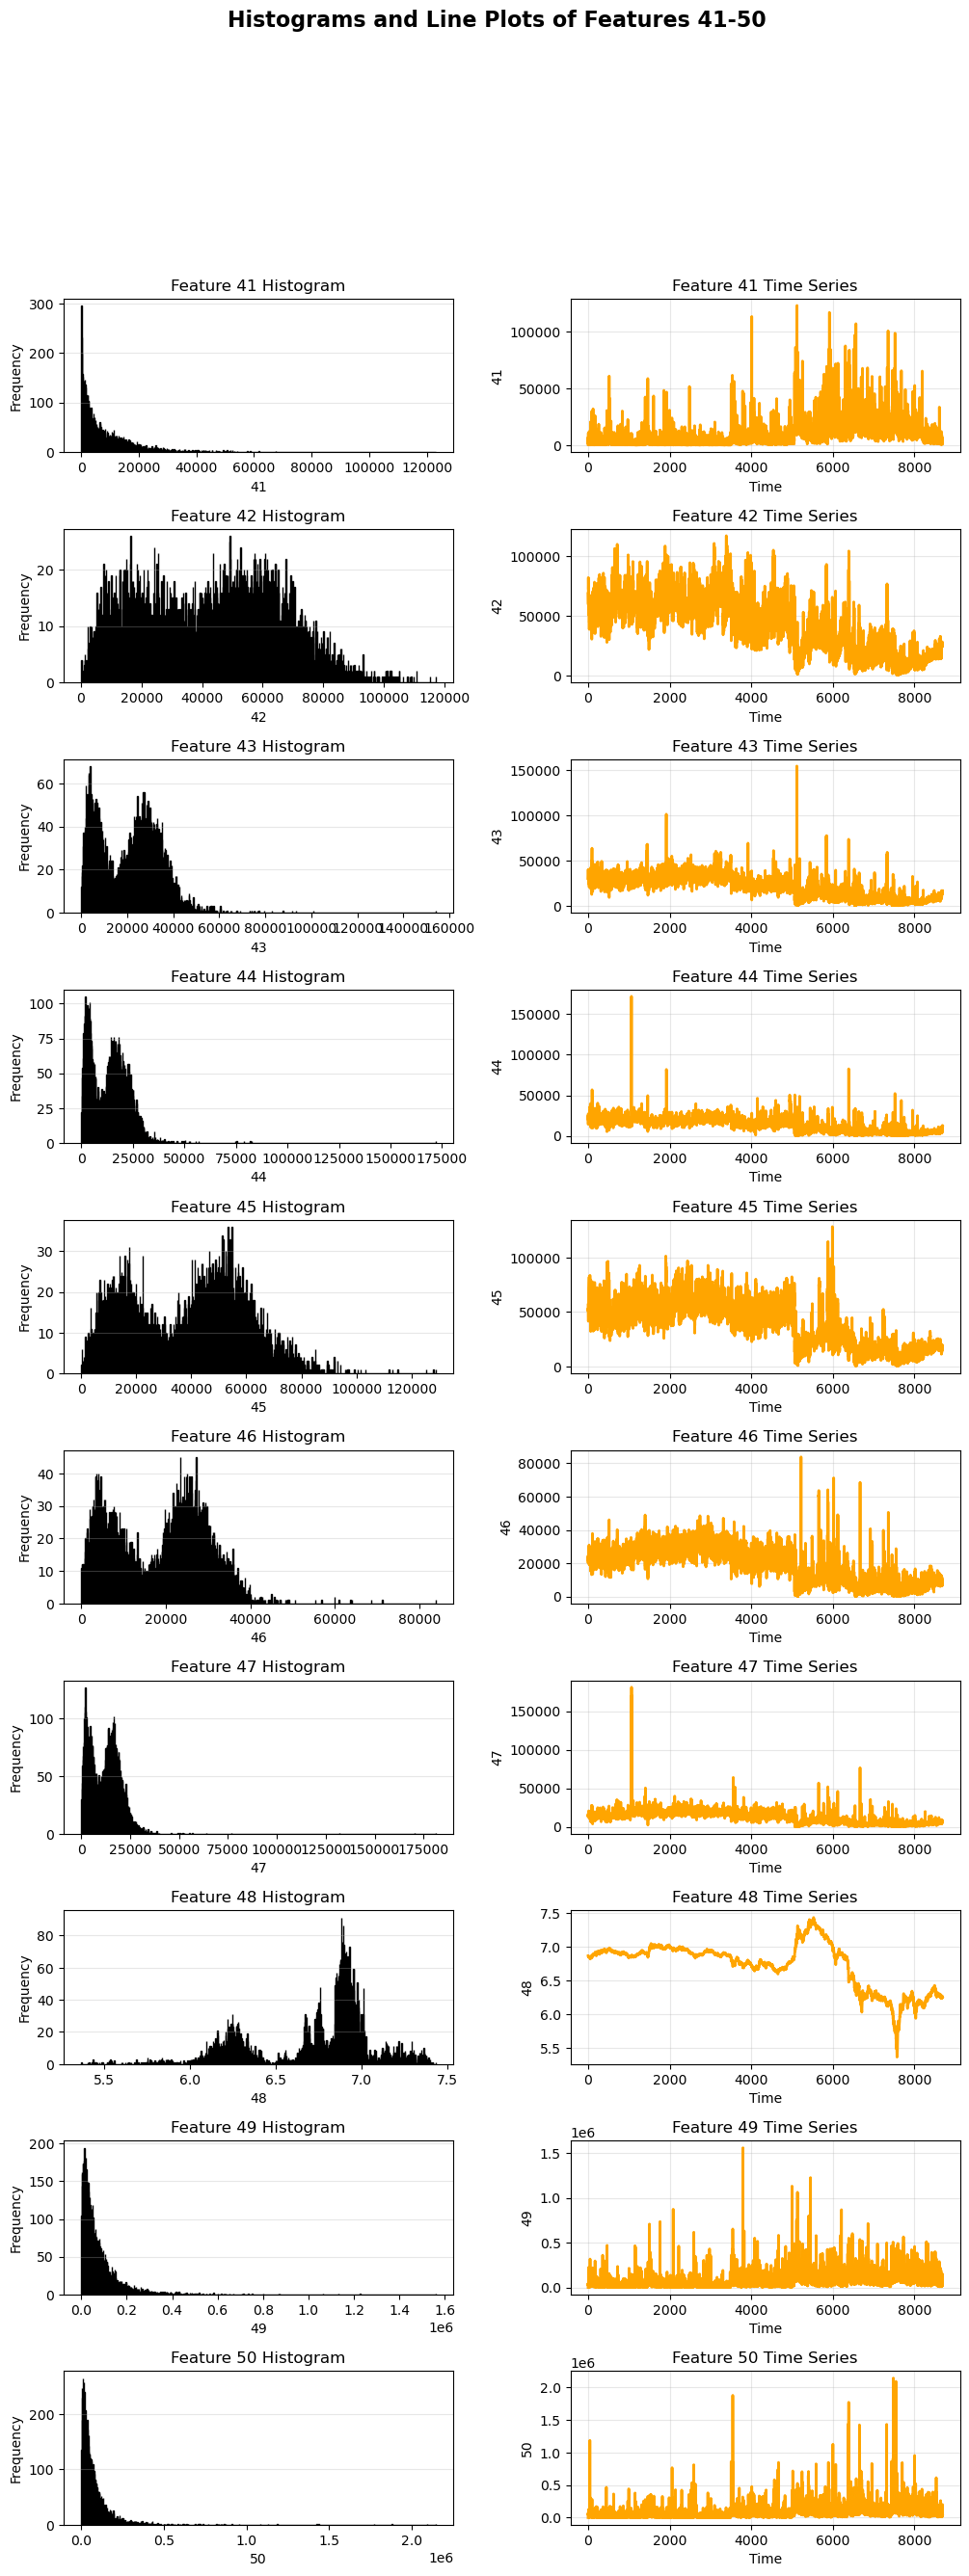

In [129]:
cols_to_plot = [str(i) for i in range(41, 51)]  # Next 10 columns
n = len(cols_to_plot)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(cols_to_plot):
    # Histogram
    axes[i, 0].hist(df[col], bins=1000, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Feature {col} Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Line plot
    axes[i, 1].plot(df.index, df[col], color='orange', linewidth=2)
    axes[i, 1].set_title(f'Feature {col} Time Series')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Histograms and Line Plots of Features 41-50', fontsize=16, fontweight='bold')
plt.show()


### Observations

1. Features 41, 43, 44, 47,49 and 50 are also highly oscillating and hard to interpret.

2. Features 42, 45 and 46 look to be resembling a bimodal distribution. I dont have much idea what these features could be representing.

3. Feature 48 also looks very similar to feature 1. Could also be a transformation of this feature.

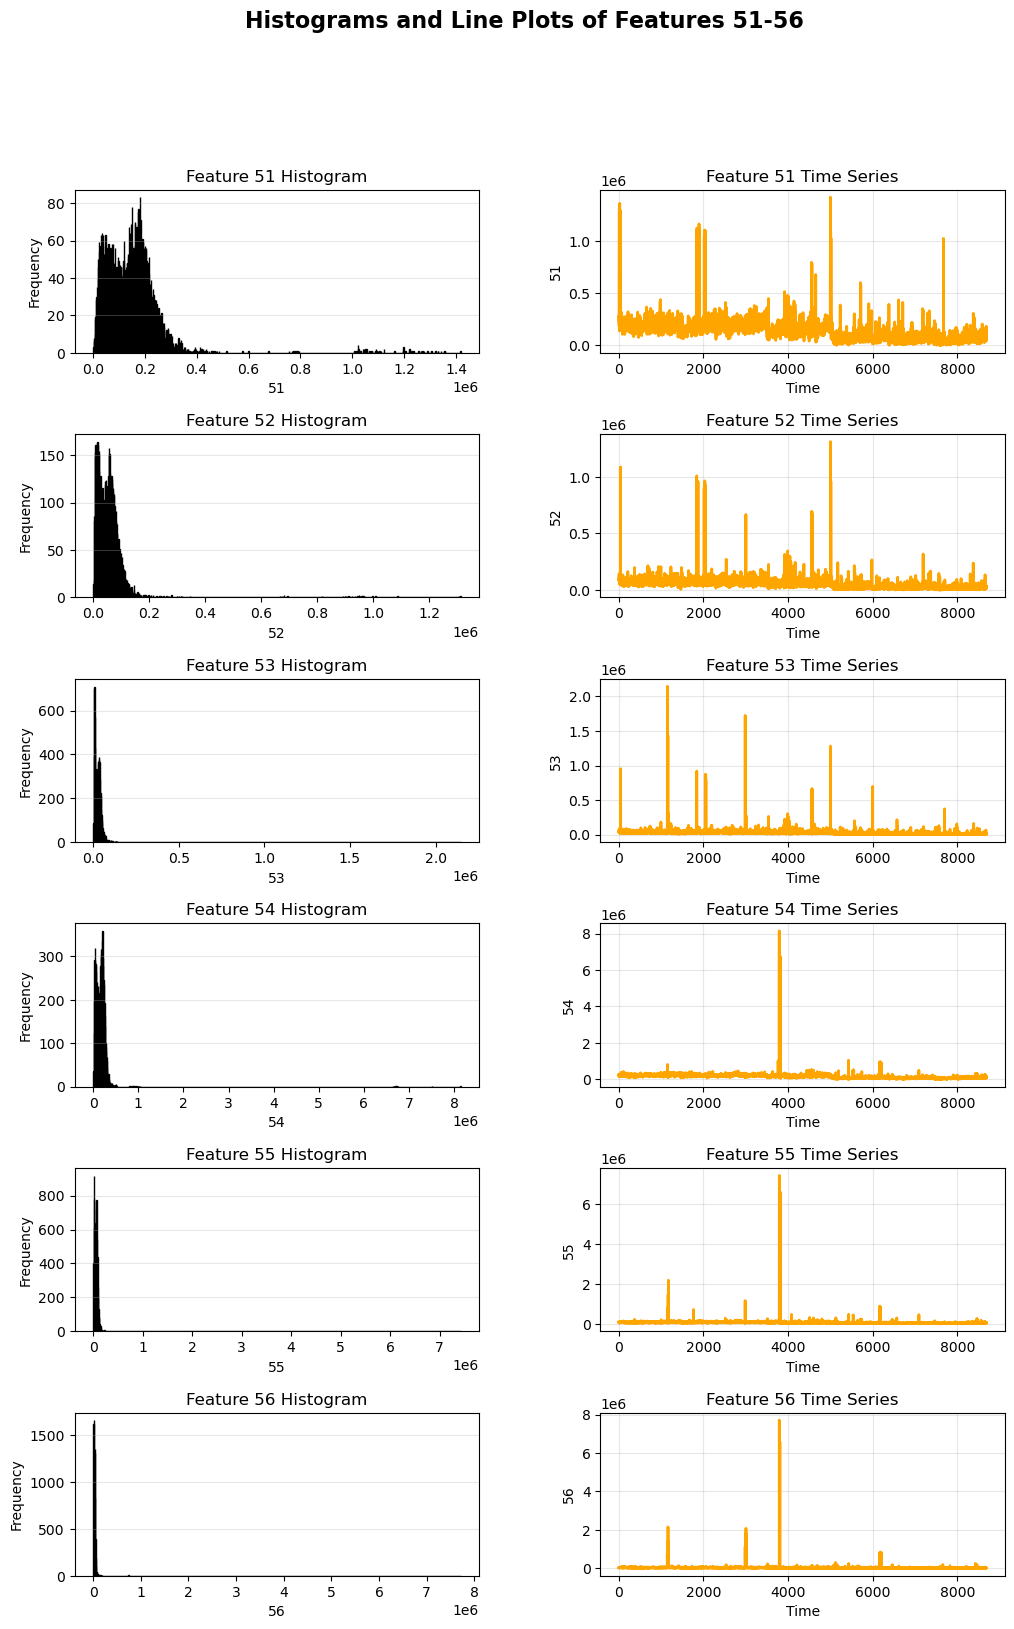

In [130]:
cols_to_plot = [str(i) for i in range(51, 57)]  # Last 6
n = len(cols_to_plot)

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n*3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, col in enumerate(cols_to_plot):
    # Histogram
    axes[i, 0].hist(df[col], bins=1000, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Feature {col} Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Line plot
    axes[i, 1].plot(df.index, df[col], color='orange', linewidth=2)
    axes[i, 1].set_title(f'Feature {col} Time Series')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.suptitle('Histograms and Line Plots of Features 51-56', fontsize=16, fontweight='bold')
plt.show()


### Observations

1. Features 51-56 display highly volatile values, oscillating from 0 to very large numbers. These are also visually hard to interpret 

# Univariate Feature Visualisations and Stats

Some initial observations I have:

After plotting these features, a large number of them do not follow a continuous time series, and therefore it is not very useful to plot them in this way. 

For those that do, such as features 11, 1, 30, 48 and 39, these all seem to be very correlated to each other and I believe are closely correlated to the asset price, which I believe is column 1.

I will now create a correlation heatmap and use hierarchical clustering to group together clusters on the heatmap.

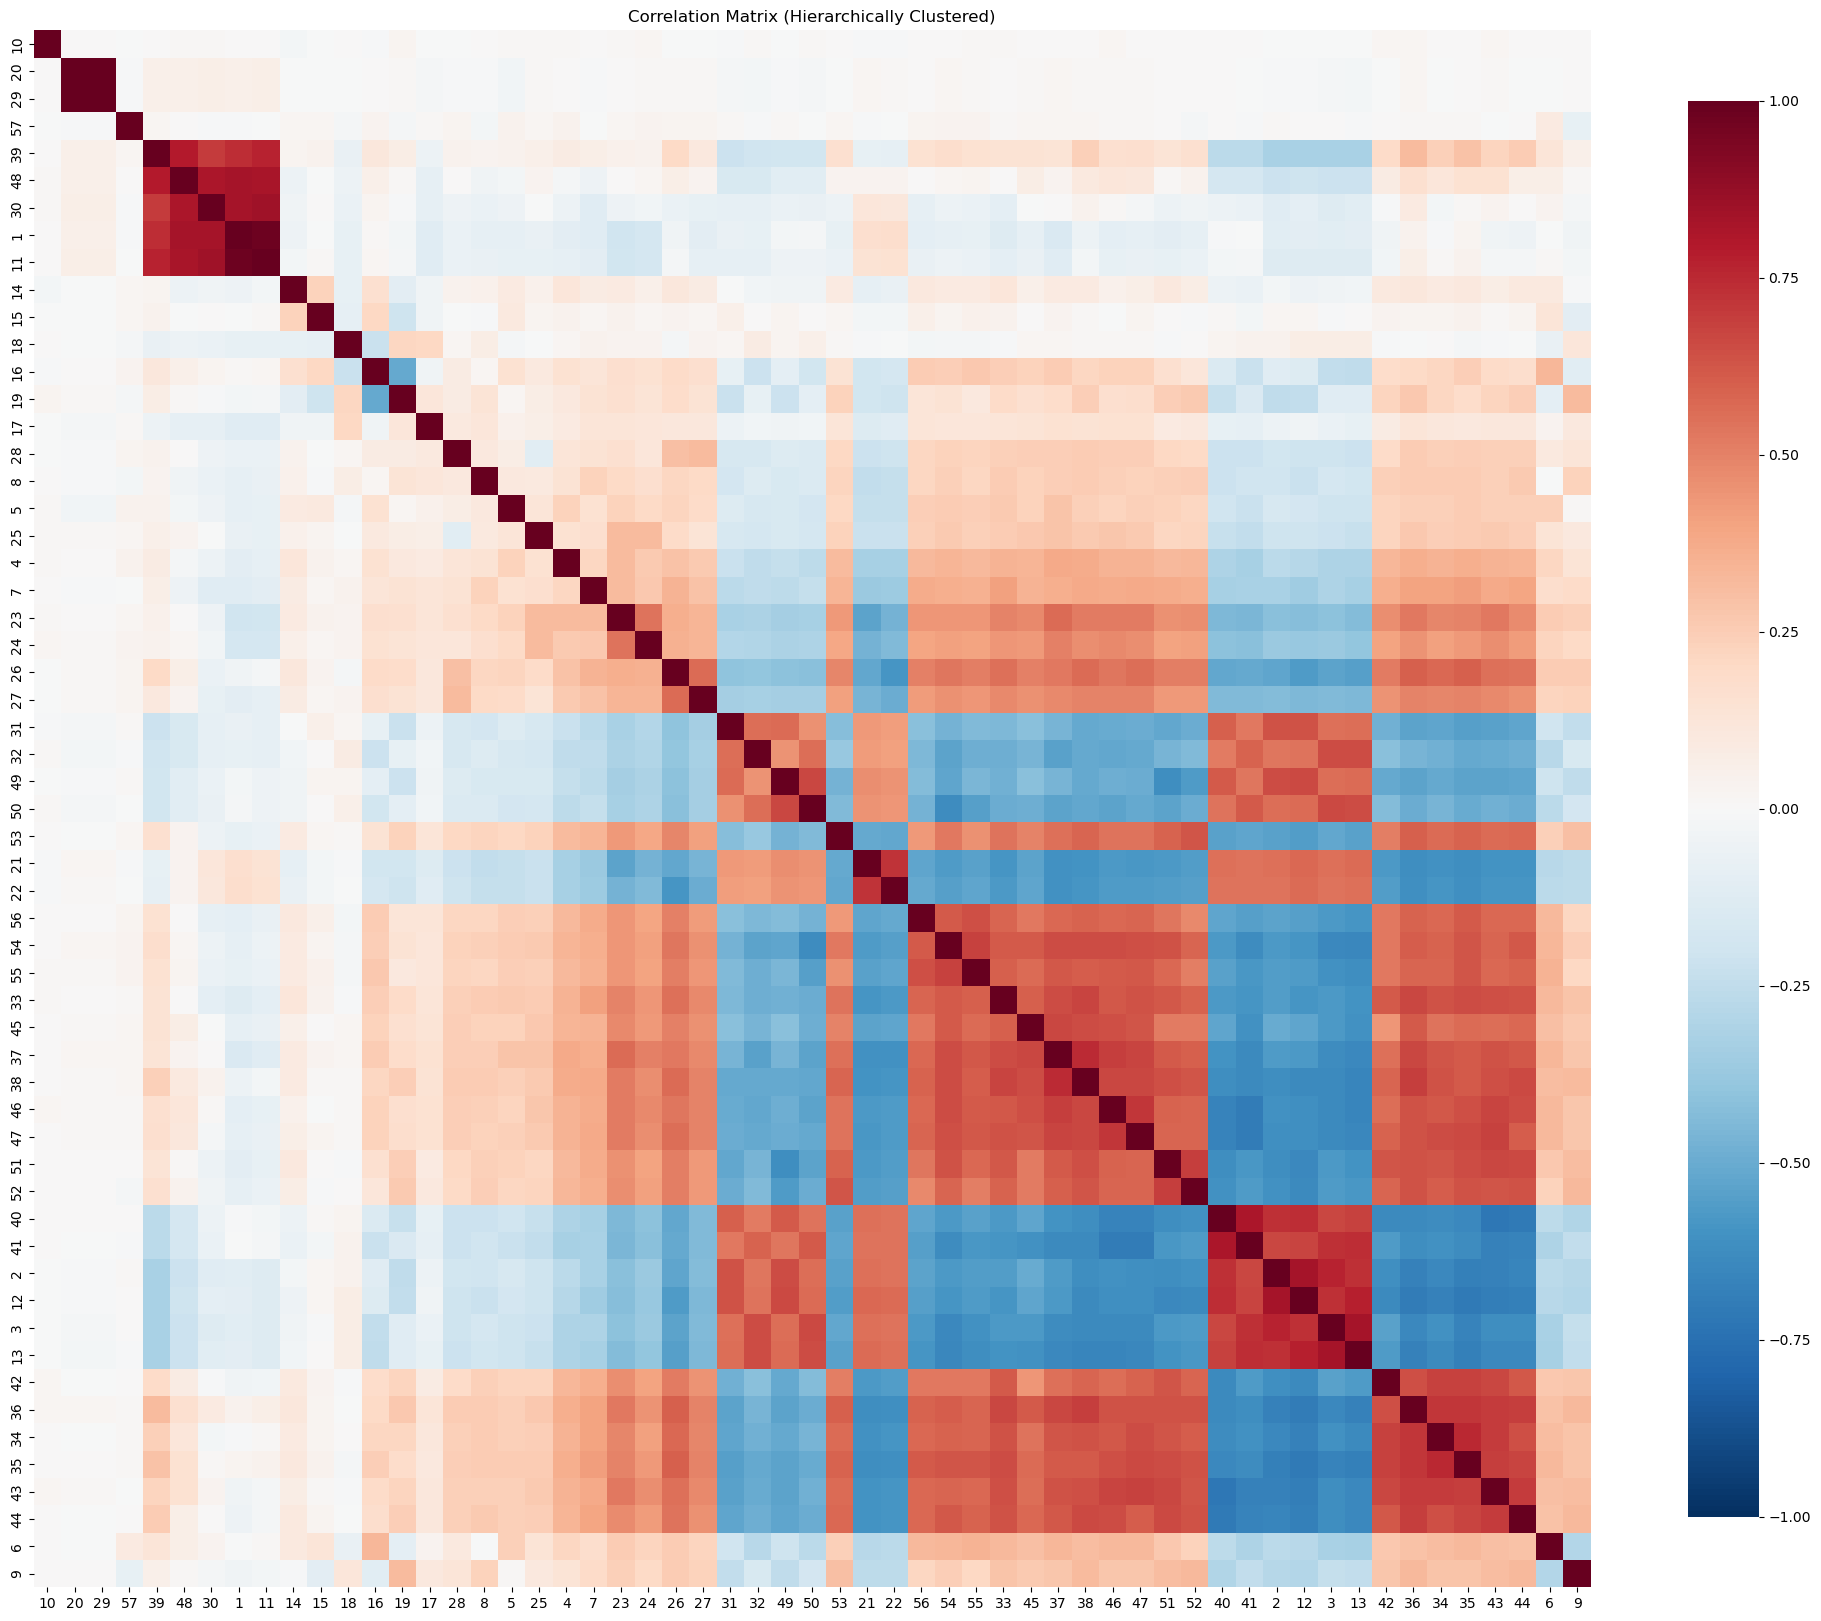

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform


# Compute Correlation Matrix
corr_matrix = train.corr(method='spearman')

# Convert correlation to distance metric
dissimilarity = 1 - corr_matrix.abs()
distance_matrix = squareform(dissimilarity)

# Perform hierarchical clustering
linkage = hierarchy.linkage(distance_matrix, method='average')

# Get the order of features from clustering
dendro = hierarchy.dendrogram(linkage, no_plot=True)
ordered_indices = dendro['leaves']

# Reorder correlation matrix
ordered_features = corr_matrix.columns[ordered_indices]
corr_reordered = corr_matrix.loc[ordered_features, ordered_features]

# Plot
plt.figure(figsize=(20, 18))
sns.heatmap(corr_reordered, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, 
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Hierarchically Clustered)')
plt.tight_layout()
plt.show()

In [132]:
# Get all correlations in descending order
corr_matrix_abs = corr_matrix.abs()
threshold = 0.75

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix_abs.iloc[i, j] > threshold:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

train_high_corr = pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)
print(f"Pairs with |corr| > {threshold}: {len(train_high_corr)}")
train_high_corr

Pairs with |corr| > 0.75: 15


,feature1,feature2,correlation
10,20,29,1.000000
0,1,11,0.979740
6,11,30,0.845257
2,1,48,0.834366
1,1,30,0.833908
4,2,12,0.833620
5,3,13,0.833007
8,11,48,0.820840
11,30,48,0.818907
14,40,41,0.813326


# Correlation and other plots

We use Spearman correlation (better than Pearson for outlier robustness) and find large high-correlation clusters.

I also created a table displaying pairs with an absolute correlation higher than 0.80.

Some of these pairs are expected after looking at the histogram and line plots, like [1, 11, 39, 30, 48] which are most likely showing some form of transformation of the asset price.

[20, 29] are clearly scalar transformations of each other. Could be something like bid-ask spread.

Features [40, 41, 2, 12, 3, 13] form a strongly correlated cluster, suggesting they capture the same underlying market process.

Interestingly, there is also a slightly strong negative correlation between the above cluster [40, 41, 2, 12, 3, 13] and [52, 51, 47, 46, 38, 37, 45, 33, 55, 54, 56]. This may be useful later on, although I am not quite sure what they could be representing or how relevant they are to the target.

There are also some similar clusters, such as [42, 36, 44, 34, 35, 43], that also have a mildly strong negative correlation with [40, 41, 2, 12, 3, 13]. 

There are 15 pairs of features with > .75 correlation. This is good information for model selection 

I will now plot a bar chart showing each feature's correlation to the target variable. This will be important to see whether these correlated clusters will be of use in predicting returns.

In [137]:
import matplotlib.pyplot as plt
train_for_target = train.columns.drop(['57','1','11','39','30','48'])

corr_to_target = pd.Series(index = train.columns[:57])
for i in train_for_target: # dropping columns related to price and returns itself since these will obviously have a very high correlation to returns
    corr_to_target[i] = train[i].corr(train['57'])

/var/folders/6w/spcdkr4d2m70f9_0rbp6gldw0000gn/T/ipykernel_43738/3340502229.py:4: FutureWarning:

The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.



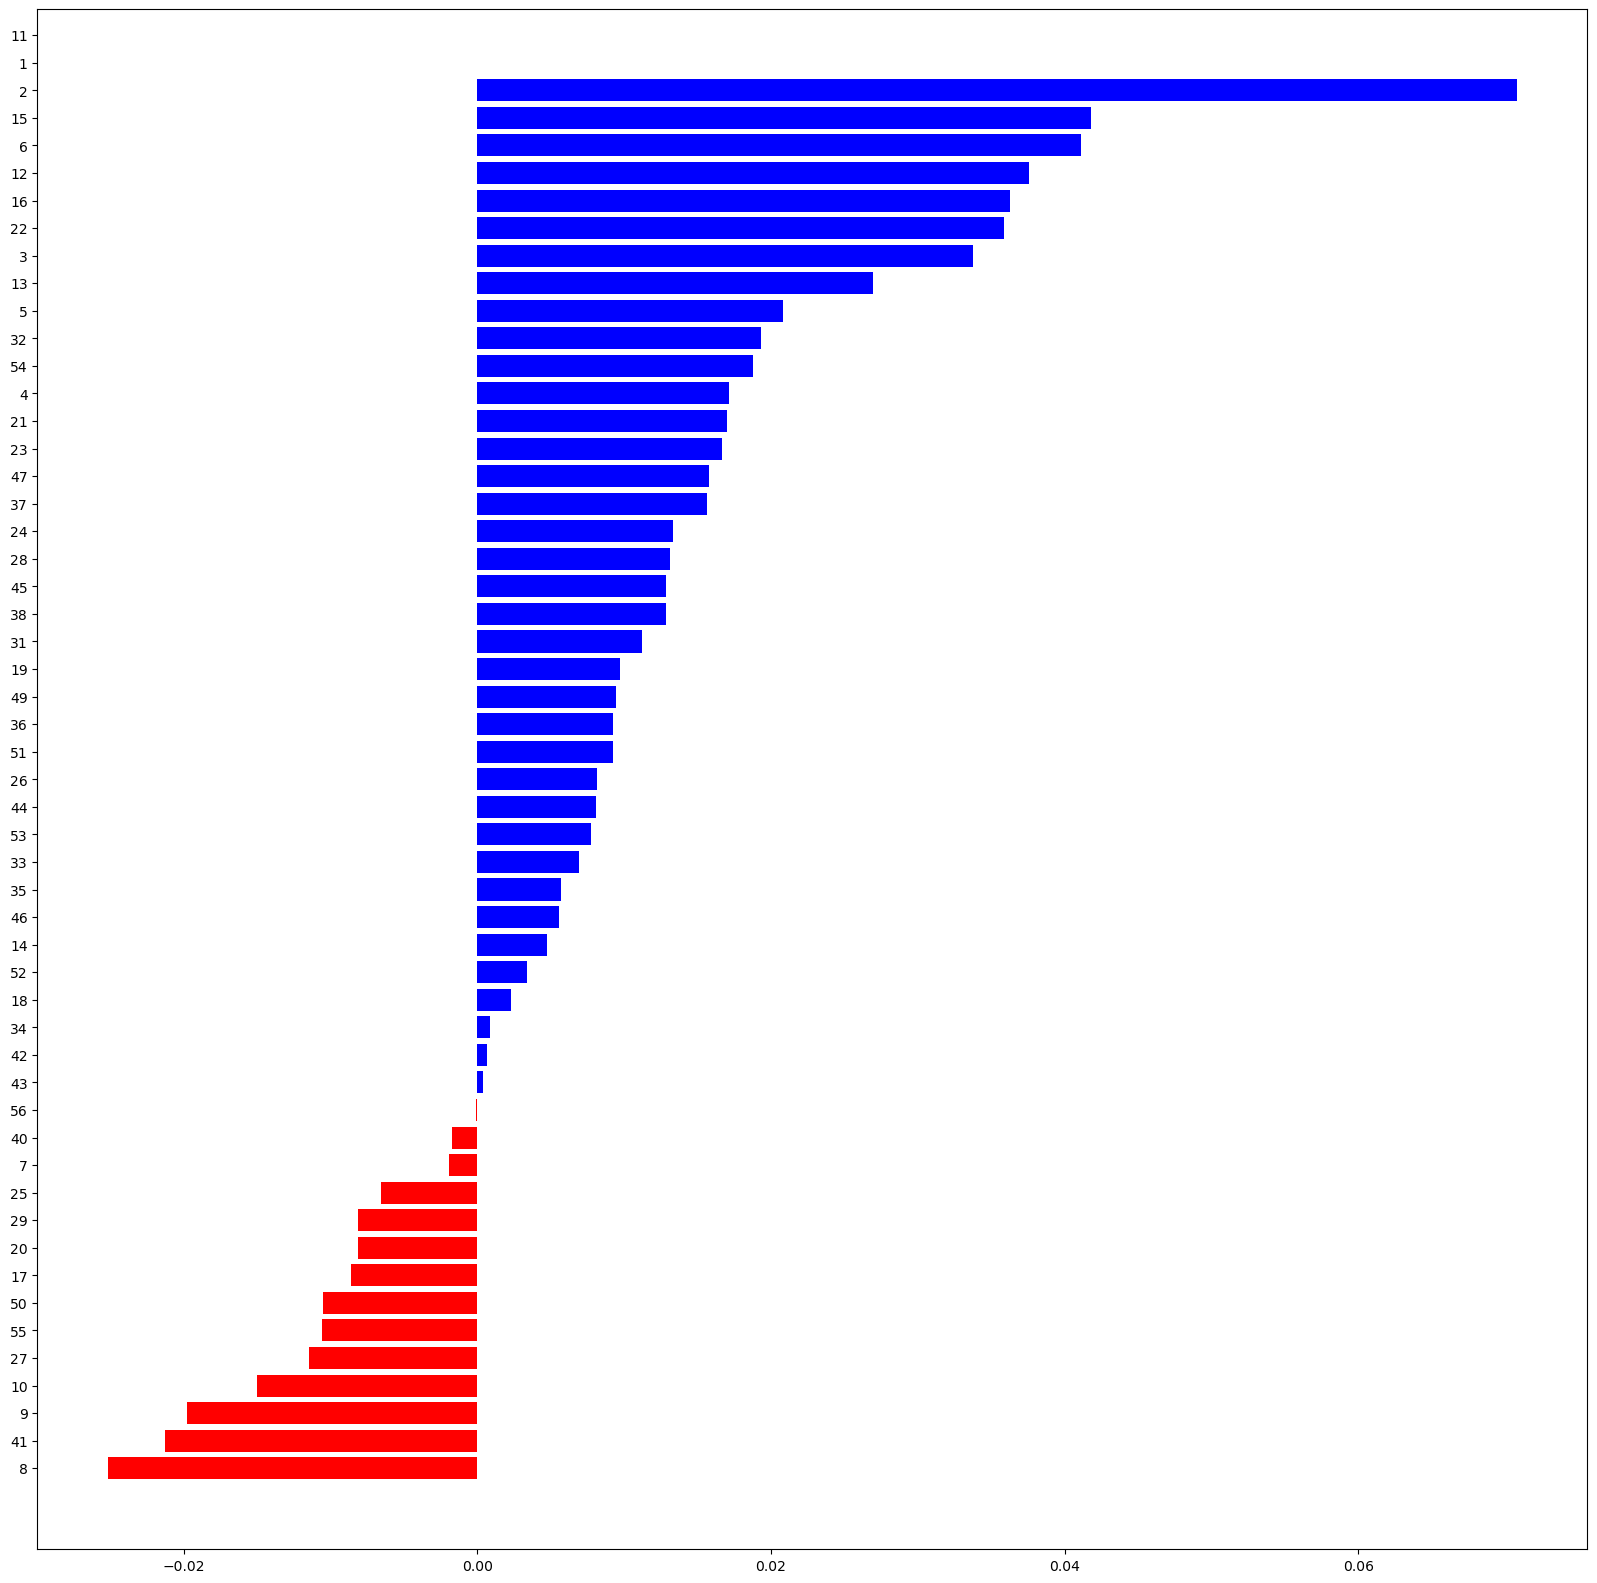

In [134]:
corr_to_target = corr_to_target.sort_values() # sorting in terms of correlation to returns
plt.figure(figsize=(20,20))
plt.barh(y=corr_to_target.index, width = corr_to_target, color = ['b' if i>0 else 'r' for i in corr_to_target])
plt.show()

In [135]:
corr_to_target 

8    -0.025163
41   -0.021310
9    -0.019799
10   -0.014978
27   -0.011445
55   -0.010569
50   -0.010494
17   -0.008595
20   -0.008105
29   -0.008105
25   -0.006543
7    -0.001966
40   -0.001754
56   -0.000083
43    0.000362
42    0.000631
34    0.000830
18    0.002272
52    0.003369
14    0.004743
46    0.005548
35    0.005667
33    0.006907
53    0.007725
44    0.008077
26    0.008121
51    0.009207
36    0.009265
49    0.009433
19    0.009680
31    0.011178
38    0.012812
45    0.012838
28    0.013109
24    0.013305
37    0.015642
47    0.015748
23    0.016665
21    0.016963
4     0.017119
54    0.018757
32    0.019285
5     0.020777
13    0.026964
3     0.033751
22    0.035892
16    0.036289
12    0.037538
6     0.041127
15    0.041761
2     0.070796
1          NaN
11         NaN
30         NaN
39         NaN
48         NaN
57         NaN
dtype: float64

This plot is useful to show me which columns and clusters are most correlated with returns of this asset. 

Observations:

1. The correlations range roughly between –0.025 and +0.07, indicating that no single feature is strongly linearly related to the target.

2. The relationship between individual features and returns is weak on a singular basis, which is common in a noisy, high-dimensional time series.

3. The most positively correlated features are Feature 2 (0.071), Feature 6 (0.041), Feature 15 (0.042), Feature 12 (0.038), Feature 16 (0.036), and Feature 22 (0.036).

4. The most negatively correlated features are Feature 8 (–0.025) and Feature 41 (–0.021), indicating a very mild inverse relationship.

Overall, the weak correlations suggest that predicting returns may rely on subtle, nonlinear patterns or interactions rather than strong single-feature dependencies. 

However, this is not a certainty, and the weak correlations could just be a result of a noisy financial time series.

# Model Fitting

1. The modelling strategy is designed to employ a diverse set of machine learning methods, including Lasso, Ridge, and Random Forest. 

2. Lasso and ridge regression are chosen for their regularization properties, which are expected to prevent overfitting and manage multicollinearity.

3. Random Forest is included for its ability to capture complex, non-linear relationships and its robustness to outliers, providing a strong ensemble baseline. 

4. Feature selection will be done using Lasso. This is anticipated to simplify the model, improve interpretability, and potentially enhance predictive performance by removing noisy features. 

5. For robust model evaluation, TimeSeriesSplit will be utilised for cross-validation. This method ensures that models are trained on past information and validated on future, unseen data. This provides a more realistic assessment of their ability to generalise in a time-series context.




Total usable features after cleaning: 51

Running LassoCV for feature selection...

Selected 14 features out of 51
Selected features: ['2', '6', '8', '9', '15', '16', '22', '36', '37', '38', '41', '47', '50', '54']

===== Training models (All Features) =====

Training Lasso...

Training Ridge...

Training Random Forest...


===== Training models (Selected Features) =====

Training Lasso...

Training Ridge...

Training Random Forest...


SUMMARY RESULTS — All Features
        Model   Mean R²   Std R²  Mean Corr  Std Corr  Mean RMSE  RMSE / Std(y)
        Lasso  0.002433 0.004545   0.072797  0.024682   0.000756       0.903203
        Ridge -0.081929 0.125382   0.047201  0.046367   0.000768       0.917670
Random Forest  0.003081 0.014653   0.085535  0.054613   0.000758       0.906107

SUMMARY RESULTS — Selected Features
        Model  Mean R²   Std R²  Mean Corr  Std Corr  Mean RMSE  RMSE / Std(y)
        Lasso 0.005161 0.005338   0.097359  0.022340   0.000755       0.901966
        Ridg

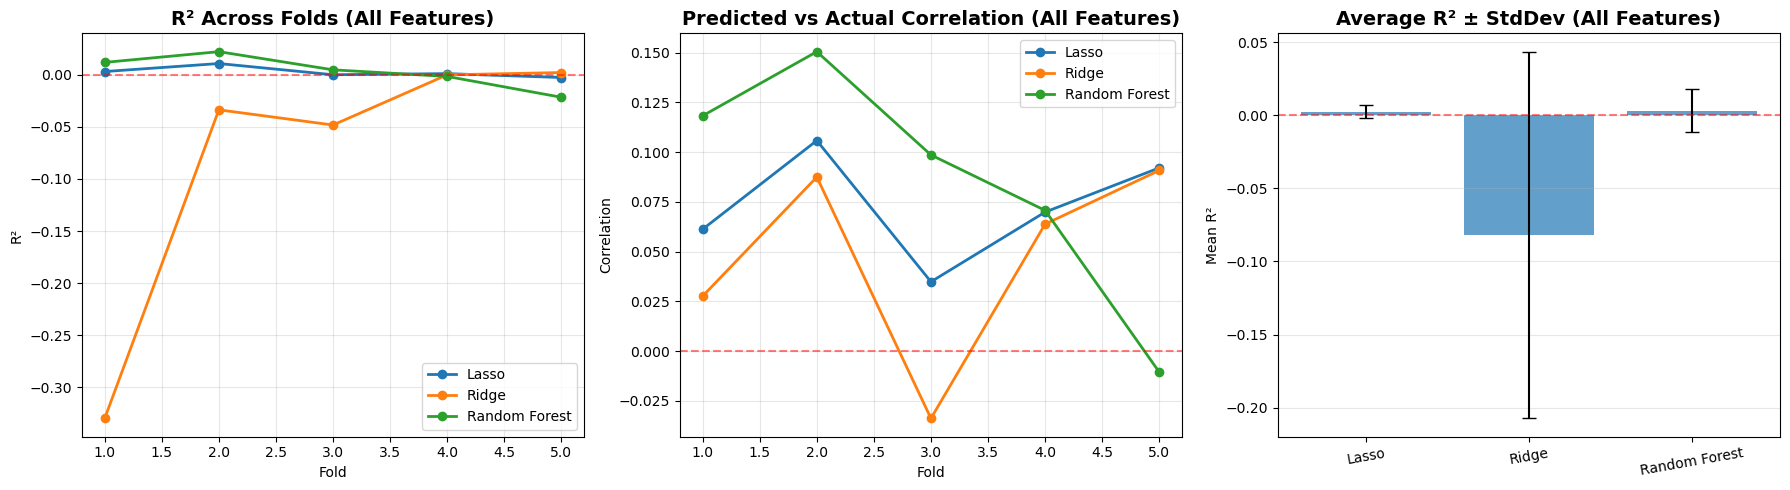

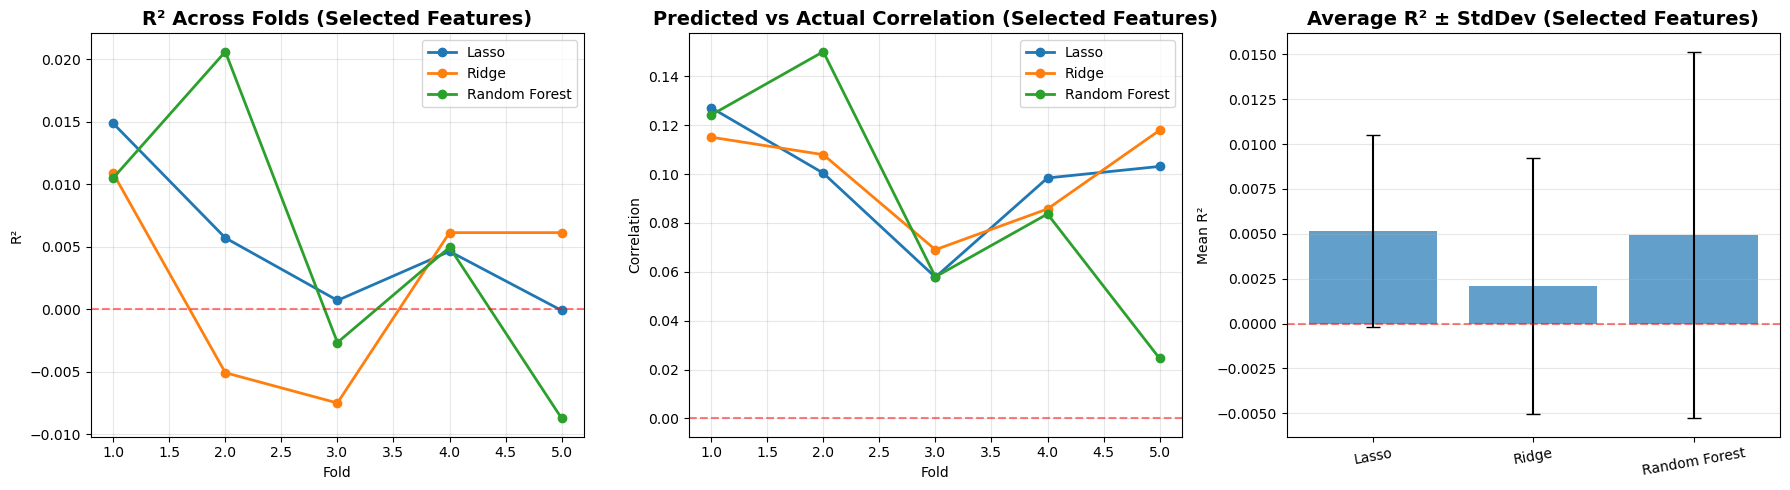


COMPARISON SUMMARY (All vs Selected Features)
        Model  Mean R² (All)  Std R² (All)  Mean Corr (All)  Std Corr (All)  Mean RMSE (All)  RMSE / Std(y) (All)  Mean R² (Selected)  Std R² (Selected)  Mean Corr (Selected)  Std Corr (Selected)  Mean RMSE (Selected)  RMSE / Std(y) (Selected)
        Lasso       0.002433      0.004545         0.072797        0.024682         0.000756             0.903203            0.005161           0.005338              0.097359             0.022340              0.000755                  0.901966
        Ridge      -0.081929      0.125382         0.047201        0.046367         0.000768             0.917670            0.002106           0.007117              0.099127             0.018817              0.000755                  0.901667
Random Forest       0.003081      0.014653         0.085535        0.054613         0.000758             0.906107            0.004932           0.010214              0.088066             0.044974              0.000756    

In [136]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

# Inital Manual Feature Selection 
X_all = train.drop(columns=['1','11','39','30','48','57']) # Dropping columns related to column 1 since this is used to calculate our target and therefore wil have high correlation to the target
y = train[target_col]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=X_all.columns)

print(f"\nTotal usable features after cleaning: {X_all.shape[1]}")


# Feature Selection using Lasso

print("\nRunning LassoCV for feature selection...\n")

lasso_selector = LassoCV(cv=5, random_state=42, n_jobs=-1)
lasso_selector.fit(X_scaled, y)

selected_features = X_all.columns[lasso_selector.coef_ != 0]
print(f"Selected {len(selected_features)} features out of {len(X_all.columns)}")
print("Selected features:", selected_features.tolist())

X_selected = X_all[selected_features]
X_scaled_selected = X_scaled[selected_features] # Scaling done for Lasso


# Walk Forward Validation and Model setup

tscv = TimeSeriesSplit(n_splits=5)

def run_models(X_data, label): # Function for running models using both selected features from Lasso and all features
    results = {
        'Lasso': {
            'model': LassoCV(cv=5, random_state=42, n_jobs=-1),
            'X': X_data,
            'r2': [], 'mse': [], 'corr': []
        },
        'Ridge': {
            'model': RidgeCV(cv=5),
            'X': X_data,
            'r2': [], 'mse': [], 'corr': []
        },
        'Random Forest': {
            'model': RandomForestRegressor(
                n_estimators=200,
                min_weight_fraction_leaf=0.005,
                max_features='sqrt',
                random_state=42,
                n_jobs=-1
            ),
            'X': X_data,
            'r2': [], 'mse': [], 'corr': []
        }
    }

    print(f"\n===== Training models ({label}) =====\n")

    for model_name, config in results.items():
        print(f"Training {model_name}...")
        for fold, (train_idx, val_idx) in enumerate(tscv.split(config['X'])):
            X_train, X_val = config['X'].iloc[train_idx], config['X'].iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = config['model']
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            r2 = r2_score(y_val, y_pred)
            mse = mean_squared_error(y_val, y_pred)
            corr = np.corrcoef(y_val, y_pred)[0, 1]

            config['r2'].append(r2)
            config['mse'].append(mse)
            config['corr'].append(corr)

        print()

    return results


# Run both scenarios

results_all = run_models(X_scaled, "All Features")
results_sel = run_models(X_scaled_selected, "Selected Features")


# Summarise

def summarise_results(results_dict, label):
    print("\n" + "="*90)
    print(f"SUMMARY RESULTS — {label}")
    print("="*90)

    target_std = y.std()
    summary_data = []
    for model_name, config in results_dict.items():
        mean_r2 = np.mean(config['r2'])
        std_r2 = np.std(config['r2'])
        mean_corr = np.mean(config['corr'])
        std_corr = np.std(config['corr'])
        mean_rmse = np.mean(np.sqrt(config['mse']))
        rmse_over_std = mean_rmse / target_std

        summary_data.append({
            'Model': model_name,
            'Mean R²': mean_r2,
            'Std R²': std_r2,
            'Mean Corr': mean_corr,
            'Std Corr': std_corr,
            'Mean RMSE': mean_rmse,
            'RMSE / Std(y)': rmse_over_std
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    return summary_df


summary_all = summarise_results(results_all, "All Features")
summary_sel = summarise_results(results_sel, "Selected Features")



# Visualisation

def plot_results(results_dict, label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # R² per fold
    ax = axes[0]
    for model_name, config in results_dict.items():
        ax.plot(range(1, 6), config['r2'], marker='o', label=model_name, linewidth=2)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f"R² Across Folds ({label})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Fold")
    ax.set_ylabel("R²")
    ax.legend()
    ax.grid(alpha=0.3)

    # Correlation comparison
    ax = axes[1]
    for model_name, config in results_dict.items():
        ax.plot(range(1, 6), config['corr'], marker='o', label=model_name, linewidth=2)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f"Predicted vs Actual Correlation ({label})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Fold")
    ax.set_ylabel("Correlation")
    ax.legend()
    ax.grid(alpha=0.3)

    # Mean R² ± StdDev
    ax = axes[2]
    x = np.arange(len(results_dict))
    means = [np.mean(cfg['r2']) for cfg in results_dict.values()]
    stds = [np.std(cfg['r2']) for cfg in results_dict.values()]
    ax.bar(x, means, yerr=stds, capsize=5, alpha=0.7)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(results_dict.keys(), rotation=10)
    ax.set_ylabel("Mean R²")
    ax.set_title(f"Average R² ± StdDev ({label})", fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_results(results_all, "All Features")
plot_results(results_sel, "Selected Features")


# Compare results 

compare_df = summary_all.merge(summary_sel, on="Model", suffixes=(" (All)", " (Selected)"))
print("\n" + "="*90)
print("COMPARISON SUMMARY (All vs Selected Features)")
print("="*90)
print(compare_df.to_string(index=False))



## Observations:

1. Overall, removal of the 'non-important' features through Lasso results in a slightly better predictive power. These features can therefore be removed on the grounds of uninterpretability and non-importance.

2. Analysis of model performance metrics reveals that feature selection using LassoCV is beneficial. 

3. For Lasso and Ridge regression, this led to a notable improvement in R² and reduced standard deviation of R², indicating more stable and consistent models. Random Forest also showed a slight R² increase. Also, the mean correlation between predicted and actual values generally increased across all models with selected features. 

4. The low R² of order 0.1% makes sense since it is a noisy financial dataset.

5. With the use of selected features, Lasso Regression outperforms Ridge and Random Forest, as seen with a higher R². Despite these values being close for Lasso and Random Forest, I would choose to use Lasso Regression due to the lower complexity and it therefore being less prone to overfitting.

6. Lasso Beating an ensembling method like Random Forest may imply that the dataset's underlying predictive relationships are more linear and that there may be a high volume of noisy or irrelevant features.

